# Fridge to Recipe

### Import libraries and dataset

## Visualization of the Data

In [3]:
import pandas as pd
df = pd.read_csv('./data/recipes_data.csv')

print(df.shape)
df.head()


(2231142, 7)


,title,ingredients,directions,link,source,NER,site
0,No-Bake Nut Cookies,"[""1 c. firmly packed brown sugar"", ""1/2 c. eva...","[""In a heavy 2-quart saucepan, mix brown sugar...",www.cookbooks.com/Recipe-Details.aspx?id=44874,Gathered,"[""bite size shredded rice biscuits"", ""vanilla""...",www.cookbooks.com
1,Jewell Ball'S Chicken,"[""1 small jar chipped beef, cut up"", ""4 boned ...","[""Place chipped beef on bottom of baking dish....",www.cookbooks.com/Recipe-Details.aspx?id=699419,Gathered,"[""cream of mushroom soup"", ""beef"", ""sour cream...",www.cookbooks.com
2,Creamy Corn,"[""2 (16 oz.) pkg. frozen corn"", ""1 (8 oz.) pkg...","[""In a slow cooker, combine all ingredients. C...",www.cookbooks.com/Recipe-Details.aspx?id=10570,Gathered,"[""frozen corn"", ""pepper"", ""cream cheese"", ""gar...",www.cookbooks.com
3,Chicken Funny,"[""1 large whole chicken"", ""2 (10 1/2 oz.) cans...","[""Boil and debone chicken."", ""Put bite size pi...",www.cookbooks.com/Recipe-Details.aspx?id=897570,Gathered,"[""chicken gravy"", ""cream of mushroom soup"", ""c...",www.cookbooks.com
4,Reeses Cups(Candy),"[""1 c. peanut butter"", ""3/4 c. graham cracker ...","[""Combine first four ingredients and press in ...",www.cookbooks.com/Recipe-Details.aspx?id=659239,Gathered,"[""graham cracker crumbs"", ""powdered sugar"", ""p...",www.cookbooks.com


In [4]:
print(df.info())
print(df.describe())
print(df.nunique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2231142 entries, 0 to 2231141
Data columns (total 7 columns):
 #   Column       Dtype 
---  ------       ----- 
 0   title        object
 1   ingredients  object
 2   directions   object
 3   link         object
 4   source       object
 5   NER          object
 6   site         object
dtypes: object(7)
memory usage: 119.2+ MB
None
                    title                                    ingredients  \
count             2231141                                        2231142   
unique            1312870                                        2226362   
top     Chicken Casserole  ["1 c. peanut butter", "1 c. sugar", "1 egg"]   
freq                 4099                                             28   

                               directions  \
count                             2231142   
unique                            2211644   
top     ["Mix all ingredients together."]   
freq                                  274   

         

In [5]:
print(df.isnull().sum())

title          1
ingredients    0
directions     0
link           0
source         0
NER            0
site           0
dtype: int64


In [6]:
type(df['NER'].iloc[0])

str

**Interpretation**

The recipe dataset contains over 2M recipes from 28 different sites. 
The dataset does luckily provide me of a NER column, which stands for Named Entity Recognition. And is a technology within NLP to scan the text and take the words to assign them to their categories. It seems that the column contains of a string, and we need to seperate the ingredients to be able to use them for the project. 

In [7]:
import ast
df['NER_parsed'] = df['NER'].apply(ast.literal_eval)
print(type(df['NER_parsed'].iloc[0]))
print(df['NER_parsed'].iloc[0])

<class 'list'>
['bite size shredded rice biscuits', 'vanilla', 'brown sugar', 'nuts', 'milk', 'butter']


In [8]:
flat_list = [ingredient for sublist in df['NER_parsed'] for ingredient in sublist]
print(len(flat_list))  
print(flat_list[:10]) 

18419930
['bite size shredded rice biscuits', 'vanilla', 'brown sugar', 'nuts', 'milk', 'butter', 'cream of mushroom soup', 'beef', 'sour cream', 'chicken breasts']


In [9]:
from collections import Counter

count = Counter(flat_list)
most_common = count.most_common(20)
print(most_common)


[('salt', 959350), ('sugar', 602734), ('butter', 502604), ('flour', 468993), ('eggs', 418586), ('onion', 386037), ('garlic', 370008), ('milk', 357388), ('water', 334886), ('vanilla', 279408), ('olive oil', 214856), ('pepper', 188745), ('brown sugar', 181384), ('egg', 172824), ('tomatoes', 169423), ('baking powder', 160592), ('lemon juice', 152447), ('cinnamon', 125062), ('sour cream', 121741), ('baking soda', 120338)]


**Interpretation**

The NER column now contains a list of ingredients. With **Counter** I wanted to see what the most common ingredients were. Most common ingredients such as 'salt', 'sugar', 'butter' and 'flour'. Will not help us very much matching the ingredients with recipes, since these are basic ingredients and used an many recipes. Next steps we will use to identify more unique ingredients is to vectorize the text with TF-IDF. 

Before doing that, we will continue with exploring the data. I would lik to see what type of recipes the data set contains. To do that we will create clusters from a sample of the datatset, to give us an idea. 

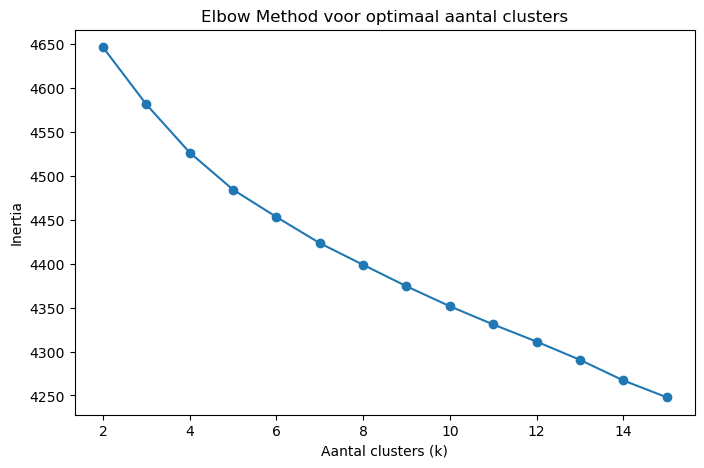

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# 1. Subset nemen voor clustering-demonstratie
sample_df = df.sample(n=5000, random_state=42).reset_index(drop=True)

# 2. NER lijsten omzetten naar strings voor TF-IDF
sample_df['NER_text'] = sample_df['NER_parsed'].apply(lambda x: ' '.join(x))

# 3. TF-IDF vectorizen
tfidf = TfidfVectorizer(max_features=2000, min_df=2, max_df=0.3)
tfidf_matrix = tfidf.fit_transform(sample_df['NER_text'])

# 4. Elbow method om optimaal aantal clusters te bepalen
inertias = []
k_range = range(2, 16)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(tfidf_matrix)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, marker='o')
plt.xlabel('Aantal clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method voor optimaal aantal clusters')
plt.show()

**Interpretation**

We can see that the curve is getting flatter between k6 and k8. Having 7 different clusters, will give us enough variaty of ingredients that will recommend a recipe.  

Cluster 0: soup, of, cream, chicken, mushroom, onion, cheese, celery, cheddar, sour
Cluster 1: baking, flour, soda, powder, vanilla, eggs, butter, milk, egg, shortening
Cluster 2: juice, lemon, orange, lime, pineapple, butter, water, oil, fresh, zest
Cluster 3: pepper, oil, garlic, onion, olive, ground, red, sauce, black, vinegar
Cluster 4: cheese, cream, cheddar, parmesan, onion, pepper, sauce, butter, mozzarella, sour
Cluster 5: milk, butter, vanilla, flour, water, eggs, cream, chocolate, egg, cinnamon


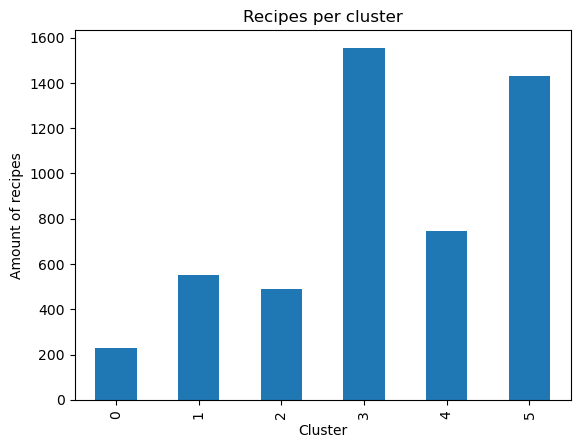

In [11]:
optimal_k = 6

kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
sample_df['cluster'] = kmeans_final.fit_predict(tfidf_matrix)

terms = tfidf.get_feature_names_out()
order_centroids = kmeans_final.cluster_centers_.argsort()[:, ::-1]

for i in range(optimal_k):
    top_terms = [terms[ind] for ind in order_centroids[i, :10]]
    print(f"Cluster {i}: {', '.join(top_terms)}")

sample_df['cluster'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Cluster')
plt.ylabel('Amount of recipes')
plt.title('Recipes per cluster')
plt.show()

**Interpretation**

These clusters give some idea of the recipe types. We can now differentiate between: 

* Cluster 0: Soups
* Cluster 1: Baking
* Cluster 2: Juices
* Cluster 3: Savory or meat dishes
* Cluster 4: Cheesy
* Cluster 5: Desserts

I'm not too content on these clusters, after some trial and error between `max_df` and `optimal_k`. I see still too much overlap between clusters. See here the overlap in cluster 1 and cluster 5. So I will try to do they same but for the column `directions`. 

In [12]:
df['directions_parsed'] = df['directions'].apply(ast.literal_eval)
print(type(df['directions_parsed'].iloc[0]))
print(df['directions_parsed'].iloc[0])

<class 'list'>
['In a heavy 2-quart saucepan, mix brown sugar, nuts, evaporated milk and butter or margarine.', 'Stir over medium heat until mixture bubbles all over top.', 'Boil and stir 5 minutes more. Take off heat.', 'Stir in vanilla and cereal; mix well.', 'Using 2 teaspoons, drop and shape into 30 clusters on wax paper.', 'Let stand until firm, about 30 minutes.']


In [13]:
# Remove special characters
# Lemmatize
import re
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
from nltk.stem.wordnet import WordNetLemmatizer
lemmatizer  = WordNetLemmatizer()

def clean_text(text):
    text = re.sub(r"[^a-zA-Z]", " ", text)
    text = re.sub(r"\b[a-zA-Z]\b"," ", text)
    #Remove all single characters from the start
    text = re.sub(r"^[a-zA-Z]\s+"," ", text)
    #Substitute multiple spaces with single space
    text = re.sub(r" +"," ", text)
    #Convert tot Lowercase
    text = text.lower()

    #Remove stopwords
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words]

    #Lemmatize
    tokens = [lemmatizer.lemmatize(w) for w in filtered_words]
    return " ".join(tokens)

sample_df = df.sample(n=5000, random_state=42).reset_index(drop=True)
sample_df['directions_text'] = sample_df['directions_parsed'].apply(lambda x: ' '.join(x))
sample_df['directions_clean'] = sample_df['directions_text'].apply(clean_text)
print(sample_df["directions_clean"].head())

0    remove tenderloin steak score meat combine rem...
1    combine ingredient slow cooker quart bury chic...
2    cook carrot cut crosswise inch piece add butte...
3    mix dry ingredient bowl add crisco cut dough c...
4    mix press baking pan approximately inch bake m...
Name: directions_clean, dtype: object


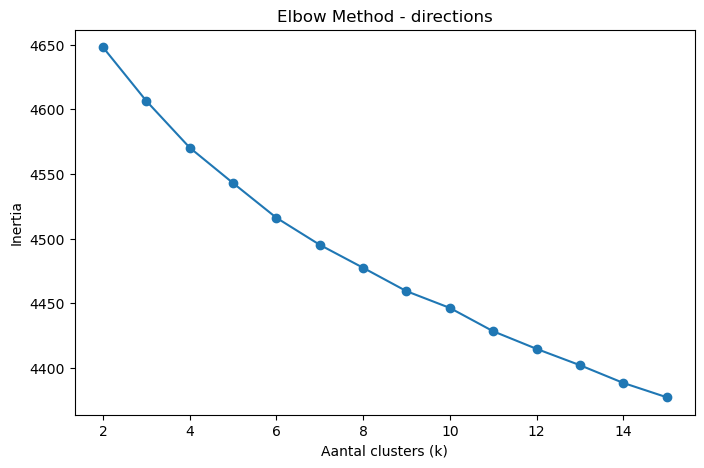

In [14]:
# 1. TF-IDF vectorizen op de schone directions-tekst
tfidf_dir = TfidfVectorizer(max_features=2000, min_df=2, max_df=0.5)
tfidf_matrix_dir = tfidf_dir.fit_transform(sample_df['directions_clean'])

# 2. Elbow method om optimaal aantal clusters te bepalen
inertias_dir = []
k_range = range(2, 16)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(tfidf_matrix_dir)
    inertias_dir.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias_dir, marker='o')
plt.xlabel('Aantal clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method - directions')
plt.show()

Cluster 0: ingredient, mix, together, bake, combine, hour, well, first, pour, bowl
Cluster 1: sugar, cool, cream, mix, water, stir, mixture, cup, chocolate, ice
Cluster 2: dough, roll, flour, ball, sheet, cookie, sugar, inch, bake, place
Cluster 3: chicken, heat, breast, cook, sauce, place, piece, pepper, rice, pan
Cluster 4: heat, cook, stir, onion, simmer, water, pepper, medium, boil, tender
Cluster 5: cheese, dish, top, bake, casserole, onion, sprinkle, sauce, mix, oven
Cluster 6: oil, pepper, slice, place, heat, salt, bowl, sauce, side, onion
Cluster 7: sugar, pan, egg, flour, beat, bake, cake, mix, vanilla, butter


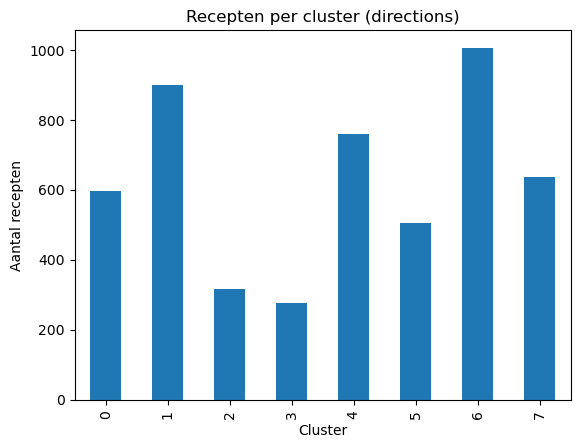

In [15]:
optimal_k_dir = 8

kmeans_dir = KMeans(n_clusters=optimal_k_dir, random_state=42, n_init=10)
sample_df['cluster_directions'] = kmeans_dir.fit_predict(tfidf_matrix_dir)

# 4. Top termen per cluster
terms_dir = tfidf_dir.get_feature_names_out()
order_centroids_dir = kmeans_dir.cluster_centers_.argsort()[:, ::-1]

for i in range(optimal_k_dir):
    top_terms = [terms_dir[ind] for ind in order_centroids_dir[i, :10]]
    print(f"Cluster {i}: {', '.join(top_terms)}")

# 5. Cluster-grootte visualiseren
sample_df['cluster_directions'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Cluster')
plt.ylabel('Aantal recepten')
plt.title('Recepten per cluster (directions)')
plt.show()

In [16]:
flat_direction_words = [word for text in sample_df['directions_clean'] for word in text.split()]
count_directions = Counter(flat_direction_words)
common_directions = count_directions.most_common(30)
print(common_directions)

[('add', 6236), ('minute', 5929), ('heat', 3710), ('pan', 2830), ('mix', 2782), ('bowl', 2663), ('stir', 2538), ('cook', 2494), ('mixture', 2440), ('bake', 2270), ('salt', 2253), ('place', 2238), ('oven', 2134), ('water', 2084), ('sugar', 2084), ('top', 1877), ('oil', 1859), ('pepper', 1856), ('cheese', 1813), ('medium', 1804), ('butter', 1786), ('egg', 1780), ('large', 1740), ('ingredient', 1664), ('pour', 1639), ('cup', 1632), ('onion', 1610), ('remove', 1600), ('combine', 1595), ('well', 1551)]


In [17]:
# Uitgebreide stopwoordenlijst: NLTK-stopwoorden + generieke kookwerkwoorden
cooking_stopwords = {
    'add', 'minute', 'heat', 'mix',  'bowl', 'stir', 'cook', 'mixture', 'salt',  'place', 'combine',
    'minutes', 'hour', 'hours', 'pan', 'together',
    'until', 'medium', 'top', 'sprinkle', 'let', 'set',
    'inch', 'degree', 'degrees', 'ingredient', 'ingredients','pour'
}
extended_stop_words = stop_words.union(cooking_stopwords)

def clean_text_directions(text):
    text = re.sub(r"[^a-zA-Z]", " ", text)
    text = re.sub(r"\b[a-zA-Z]\b", " ", text)
    text = re.sub(r"^[a-zA-Z]\s+", " ", text)
    text = re.sub(r" +", " ", text)
    text = text.lower()
    words = text.split()
    filtered_words = [word for word in words if word not in extended_stop_words]
    tokens = [lemmatizer.lemmatize(w) for w in filtered_words]
    return " ".join(tokens)

# Opnieuw cleanen met de uitgebreide stopwoordenlijst
sample_df['directions_clean_v2'] = sample_df['directions_text'].apply(clean_text_directions)

# TF-IDF opnieuw, nu met een hogere/geen max_df omdat de generieke woorden al weg zijn
tfidf_dir_v2 = TfidfVectorizer(max_features=2000, min_df=2, max_df=0.8)
tfidf_matrix_dir_v2 = tfidf_dir_v2.fit_transform(sample_df['directions_clean_v2'])

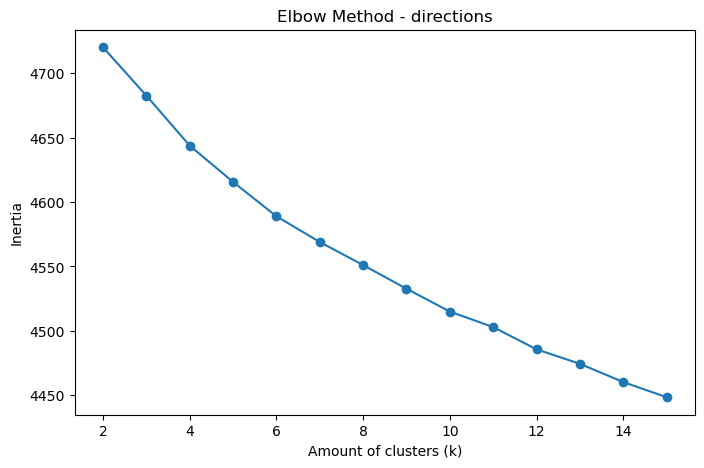

In [18]:
# 2. Elbow method om optimaal aantal clusters te bepalen
inertias_dir = []
k_range = range(2, 16)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(tfidf_matrix_dir_v2)
    inertias_dir.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias_dir, marker='o')
plt.xlabel('Amount of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method - directions')
plt.show()

Cluster 0: water, serve, well, sugar, chill, refrigerate, juice, cool, put, serving
Cluster 1: chicken, breast, sauce, pepper, rice, piece, oil, soup, onion, bake
Cluster 2: sugar, egg, beat, cake, flour, bake, vanilla, cream, butter, well
Cluster 3: onion, pepper, oil, simmer, sauce, water, tomato, garlic, skillet, tender
Cluster 4: cheese, bake, dish, casserole, oven, bread, onion, baking, butter, brown
Cluster 5: dough, roll, sheet, ball, cookie, flour, bake, sugar, baking, oven


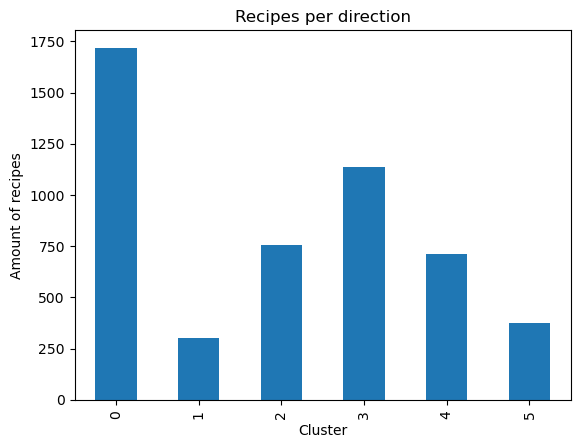

In [19]:
optimal_k_dir = 6

kmeans_dir2 = KMeans(n_clusters=optimal_k_dir, random_state=42, n_init=10)
sample_df['cluster_directions'] = kmeans_dir2.fit_predict(tfidf_matrix_dir_v2)

# 4. Top termen per cluster
terms_dir2 = tfidf_dir_v2.get_feature_names_out()
order_centroids_dir2 = kmeans_dir2.cluster_centers_.argsort()[:, ::-1]

for i in range(optimal_k_dir):
    top_terms = [terms_dir2[ind] for ind in order_centroids_dir2[i, :10]]
    print(f"Cluster {i}: {', '.join(top_terms)}")

# 5. Cluster-grootte visualiseren
sample_df['cluster_directions'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Cluster')
plt.ylabel('Amount of recipes')
plt.title('Recipes per direction')
plt.show()

**Interpretation**

Trying to cluster the recipes by `direction`, didn't give me the type of insights I wanted to. I started the cleaning process thinking I would get clusters such as Oven, Slow-cooker, Soups and cookies. These clusters don't really provide of this type of segmentation. The first clusters provide of better 'types'. 
Therefore I will stick to these clusters: 

* Cluster 0: Soups
* Cluster 1: Baking
* Cluster 2: Juices
* Cluster 3: Savory or meat dishes
* Cluster 4: Cheesy
* Cluster 5: Desserts

### TF-IDF Cosine similarity matching


In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

df['NER_text'] = df['NER_parsed'].apply(lambda x: ' '.join(x))

tfidf_matching = TfidfVectorizer()
tfidf_matrix_matching = tfidf_matching.fit_transform(df['NER_text'])

In [22]:
user_input = "chicken garlic rice"
user_vector = tfidf_matching.transform([user_input])

In [23]:
from sklearn.metrics.pairwise import cosine_similarity

similarities = cosine_similarity(user_vector, tfidf_matrix_matching)

In [24]:
import numpy as np

top_indices = similarities[0].argsort()[::-1][:5]

In [25]:
top_recipes = df.iloc[top_indices]
print(top_recipes[['title', 'NER_text']])

                                                     title      NER_text
256530                                    Chicken And Rice  rice chicken
238459                                   Pileau(Pearl O)    rice chicken
1825610  CHEEZ WHIZ White Cheddar Chicken & Broccoli Su...  rice chicken
665165                                    Chicken And Rice  rice chicken
1843760             CHEEZ WHIZ Chicken and Broccoli Dinner  rice chicken


In [26]:
top_scores = similarities[0][top_indices]
for idx, score in zip(top_indices, top_scores):
    print(f"{df.iloc[idx]['title']} — similarity: {score:.3f}")

Chicken And Rice — similarity: 0.888
Pileau(Pearl O)   — similarity: 0.888
CHEEZ WHIZ White Cheddar Chicken & Broccoli Supper — similarity: 0.888
Chicken And Rice — similarity: 0.888
CHEEZ WHIZ Chicken and Broccoli Dinner — similarity: 0.888
